`DynamicalSystem`, `LuenbergerObserver` & `MercerKernel` — Test Notebook
=========================================================================

| # | System / Topic | Key feature |
|---|----------------|-------------|
| 1 | Simple harmonic oscillator | Basic API, analytical comparison |
| 1b | Kalman–Luenberger observer (SHO) | CARE design, `LuenbergerObserver` |
| 2 | Robertson chemical kinetics | Severely stiff, 11 decades |
| 3 | Mercer Kernels | Profiles, Gram matrices, arithmetic |
| 4 | Kernel Ridge Regression | 2-D fit, LOO model selection, multi-output |
| 5 | Sobolev Kernel | Theory, special cases, smoothness comparison |
| 6 | Data Collection | `collect_data`, snapshot pairs, trajectory bundle |
| 7 | Kernel Matrices | `compute_kernel_matrices`, K₀ and M for KL synthesis |
| 8 | Observer Gain Synthesis | LMI (Eq. 19), gain matrix L (Eq. 22) |
| 9 | Koopman–Luenberger Observer Simulation | Stiff ODE, Radau solver, state estimation |

Each cell can be run independently after the **Imports** cell.

- **Example 9** — Koopman–Luenberger Observer Simulation

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)
from dynamical_system import DynamicalSystem

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
print("Imports OK.")

Imports OK.


## Example 1 — Simple Harmonic Oscillator

$$\dot{x}_1 = x_2, \qquad \dot{x}_2 = -\omega^2 x_1, \qquad y = x_1$$

A clean non-stiff system with an exact analytical solution  $y(t) = \cos(\omega t)$
for initial condition $x_0 = (1, 0)^\top$.  
We use this to confirm that the numerical output matches theory.

System : SHO
  States  : 2
  Outputs : 1
  Note    : (use solver='Radau'/'BDF' for stiff problems)
SimulationResult(solver='Radau', t=[0, 6.283], steps=600, success=True)
Max |numerical - exact|: 1.09e-07


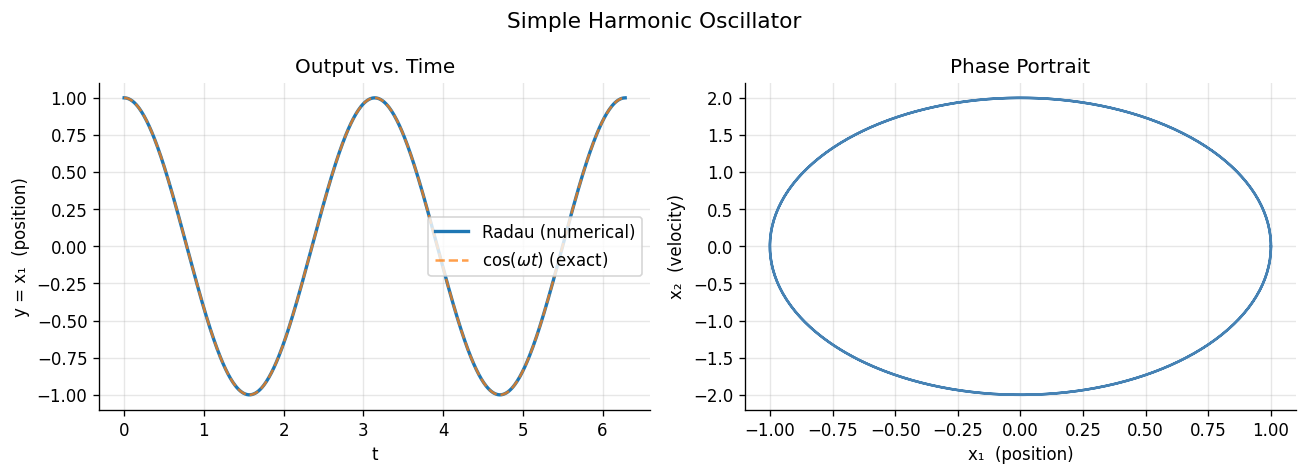

In [2]:
omega = 2.0  # natural frequency (rad/s)

def f_sho(x):
    return np.array([x[1],
                     -omega**2 * x[0]])

def h_sho(x):
    return np.array([x[0]])   # observe position only

sys_sho = DynamicalSystem(f_sho, h_sho, n_states=2, n_outputs=1, name="SHO")
print(sys_sho)

x0 = [1.0, 0.0]
T  = 4 * np.pi / omega           # two full periods
t_eval = np.linspace(0, T, 600)

result = sys_sho.simulate(x0, t_span=(0, T), t_eval=t_eval, solver='Radau')
print(result)

# Analytical ground truth
y_exact = np.cos(omega * t_eval)
max_err = np.max(np.abs(result.y[0] - y_exact))
print(f"Max |numerical - exact|: {max_err:.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(result.t, result.y[0], label="Radau (numerical)", lw=2)
ax1.plot(t_eval, y_exact, "--", label=r"$\cos(\omega t)$ (exact)", alpha=0.75)
ax1.set_xlabel("t"); ax1.set_ylabel("y = x₁  (position)")
ax1.set_title("Output vs. Time"); ax1.legend()

ax2.plot(result.x[0], result.x[1], color="steelblue")
ax2.set_xlabel("x₁  (position)"); ax2.set_ylabel("x₂  (velocity)")
ax2.set_title("Phase Portrait")

plt.suptitle("Simple Harmonic Oscillator", fontsize=13)
plt.tight_layout()
plt.show()

## Example 1b — Luenberger Observer for the SHO (Kalman Design)

The SHO is a **linear** system, so the observer gain $L$ can be chosen
optimally via the **continuous algebraic Riccati equation (CARE)** —
this is exactly the steady-state Kalman filter design.

**Setup.** The exact linearisation of $f$ and $h$ gives

$$A = \begin{bmatrix}0 & 1 \\\ -\omega^2 & 0\end{bmatrix}, \qquad
  C = \begin{bmatrix}1 & 0\end{bmatrix}$$

Assuming process noise $w \sim \mathcal{N}(0, Q_w)$ and measurement
noise $v \sim \mathcal{N}(0, R_v)$, the optimal Kalman gain is

$$L = P C^\top R_v^{-1}$$

where $P \succ 0$ solves the observer CARE

$$AP + PA^\top - PC^\top R_v^{-1}CP + Q_w = 0.$$

**Key teaching point.** Only *position* $y = x_1$ is measured;
*velocity* $x_2$ is **never observed directly**.
The observer reconstructs it from the innovation signal $y(t) - C_z z(t)$.

In [3]:
from scipy.linalg import solve_continuous_are
from luenberger_observer import LuenbergerObserver

# omega = 2.0 already defined in Example 1

# Exact linearisation of the SHO
A_lin = np.array([[0.0,        1.0],
                  [-omega**2,  0.0]])
C_lin = np.array([[1.0, 0.0]])   # position only; velocity is unobserved

# Noise covariance design parameters
Q_w = 1.0  * np.eye(2)           # process noise covariance  (2x2)
R_v = 0.01 * np.array([[1.0]])   # measurement noise covariance (1x1)
# Small R_v means: trust the sensor strongly -> observer converges fast

# Solve the observer CARE.
# scipy.solve_continuous_are(A, B, Q, R) solves  A^T X + X A - X B R^-1 B^T X + Q = 0
# The observer CARE  A P + P A^T - P C^T Rv^-1 C P + Qw = 0
# is the dual of the LQR ARE, so we pass (A.T, C.T, Q_w, R_v):
P = solve_continuous_are(A_lin.T, C_lin.T, Q_w, R_v)

L_kalman = P @ C_lin.T @ np.linalg.inv(R_v)   # shape (2, 1)

print('Riccati solution P:')
print(P.round(4))
print(f'\nKalman gain  L = {L_kalman.ravel().round(4)}')

# Eigenvalue comparison
A_obs = A_lin - L_kalman @ C_lin
eigs_plant = np.linalg.eigvals(A_lin)
eigs_obs   = np.sort_complex(np.linalg.eigvals(A_obs))

print(f'\nPlant eigenvalues          : {eigs_plant}')
print(f'Observer eigenvalues (A-LC): {eigs_obs.round(4)}')
print(f'\nAll observer eigenvalues stable: {all(e.real < 0 for e in eigs_obs)}')
print('(Plant is marginally stable +/-j*omega; observer is made strictly stable.)')

Riccati solution P:
[[0.1066 0.0677]
 [0.0677 1.1476]]

Kalman gain  L = [10.6555  6.7703]

Plant eigenvalues          : [0.+2.j 0.-2.j]
Observer eigenvalues (A-LC): [-9.5248+0.j -1.1308+0.j]

All observer eigenvalues stable: True
(Plant is marginally stable +/-j*omega; observer is made strictly stable.)


In [4]:
# Construct the LuenbergerObserver
obs_sho = LuenbergerObserver(
    system = sys_sho,       # DynamicalSystem defined in Example 1
    Az     = A_lin,         # observer state matrix  (2x2)
    Cz     = C_lin,         # observer output matrix (1x2)
    Ez     = np.eye(2),     # x_hat = z  (full-state recovery)
    L      = L_kalman,      # Kalman gain            (2x1)
    name   = 'KalmanSHO',
)
print(obs_sho)
print()

# True initial condition: at amplitude 1, zero velocity
x0_true  = np.array([1.0,  0.0])
# Observer starts from a wrong initial guess
z0_wrong = np.array([0.0, -1.5])

T_obs  = 4 * np.pi / omega      # same two-period window as Example 1
t_obs  = np.linspace(0, T_obs, 600)

r_obs = obs_sho.simulate(x0=x0_true, z0=z0_wrong,
                          t_span=(0, T_obs), t_eval=t_obs)
print(r_obs)
print(f'\nInitial error  ||e(0)||  = {np.linalg.norm(r_obs.error[:,  0]):.4f}')
print(f'Final   error  ||e(T)||  = {np.linalg.norm(r_obs.error[:, -1]):.2e}')

Observer    : KalmanSHO
  Plant     : SHO  (n_states=2, n_outputs=1)
  Order  q  : 2
  eig(A_z − L·C_z) : [-9.525+0.000j, -1.131+0.000j]
  Stable    : True

ObserverResult(solver='Radau', t=[0, 6.283], steps=600, RMS_error=1.539e-01, success=True)

Initial error  ||e(0)||  = 1.8028
Final   error  ||e(T)||  = 3.46e-04


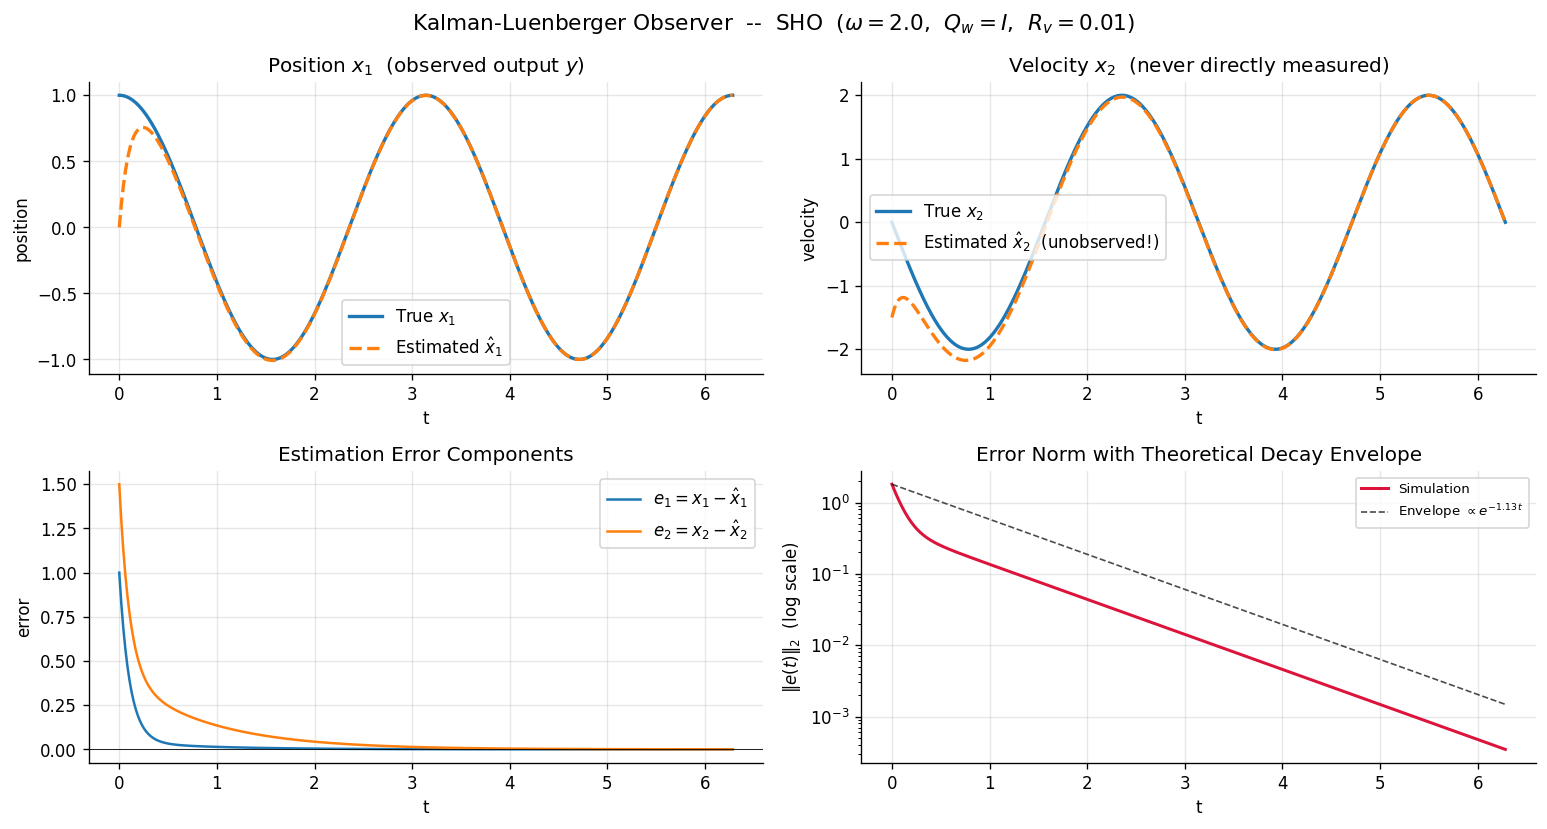

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Top-left: position x1 (this IS measured)
ax = axes[0, 0]
ax.plot(r_obs.t, r_obs.x[0],     lw=2,        label=r'True $x_1$')
ax.plot(r_obs.t, r_obs.x_hat[0], lw=2, ls='--',
        label=r'Estimated $\hat{x}_1$')
ax.set_xlabel('t'); ax.set_ylabel('position')
ax.set_title(r'Position $x_1$  (observed output $y$)')
ax.legend()

# Top-right: velocity x2 (NEVER directly measured)
ax = axes[0, 1]
ax.plot(r_obs.t, r_obs.x[1],     lw=2,        label=r'True $x_2$')
ax.plot(r_obs.t, r_obs.x_hat[1], lw=2, ls='--',
        label=r'Estimated $\hat{x}_2$  (unobserved!)')
ax.set_xlabel('t'); ax.set_ylabel('velocity')
ax.set_title(r'Velocity $x_2$  (never directly measured)')
ax.legend()

# Bottom-left: component errors
ax = axes[1, 0]
ax.plot(r_obs.t, r_obs.error[0], label=r'$e_1 = x_1 - \hat{x}_1$')
ax.plot(r_obs.t, r_obs.error[1], label=r'$e_2 = x_2 - \hat{x}_2$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('t'); ax.set_ylabel('error')
ax.set_title('Estimation Error Components')
ax.legend()

# Bottom-right: error norm (log scale) + theoretical decay envelope
ax = axes[1, 1]
err_norm = np.linalg.norm(r_obs.error, axis=0)
ax.semilogy(r_obs.t, err_norm, color='crimson', lw=1.8, label='Simulation')

# Theoretical envelope from the slower observer eigenvalue
lam_slow = sorted(np.linalg.eigvals(A_obs), key=lambda e: abs(e.real))[0]
t_th = np.linspace(0, T_obs, 300)
env  = err_norm[0] * np.exp(lam_slow.real * t_th)
ax.semilogy(t_th, env, 'k--', lw=1, alpha=0.7,
            label=fr'Envelope $\propto e^{{{lam_slow.real:.2f}\,t}}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$\|e(t)\|_2$  (log scale)')
ax.set_title('Error Norm with Theoretical Decay Envelope')
ax.legend(fontsize=8)

plt.suptitle(
    f'Kalman-Luenberger Observer  --  SHO  '
    f'($\\omega={omega}$,  $Q_w=I$,  $R_v=0.01$)',
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Example 2 — Robertson Chemical Kinetics (Severely Stiff)

A textbook benchmark for stiff ODE solvers:

$$\dot{y}_1 = -0.04\,y_1 + 10^4\,y_2 y_3$$
$$\dot{y}_2 =  0.04\,y_1 - 10^4\,y_2 y_3 - 3\times10^7 y_2^2$$
$$\dot{y}_3 =  3\times10^7 y_2^2$$

The reaction rate constants span **eleven orders of magnitude** in time.  
An explicit solver would require millions of micro-steps;  
`solver='Radau'` completes the integration comfortably.

System : Robertson
  States  : 3
  Outputs : 3
  Note    : (use solver='Radau'/'BDF' for stiff problems)
SimulationResult(solver='Radau', t=[1e-05, 1e+11], steps=800, success=True)


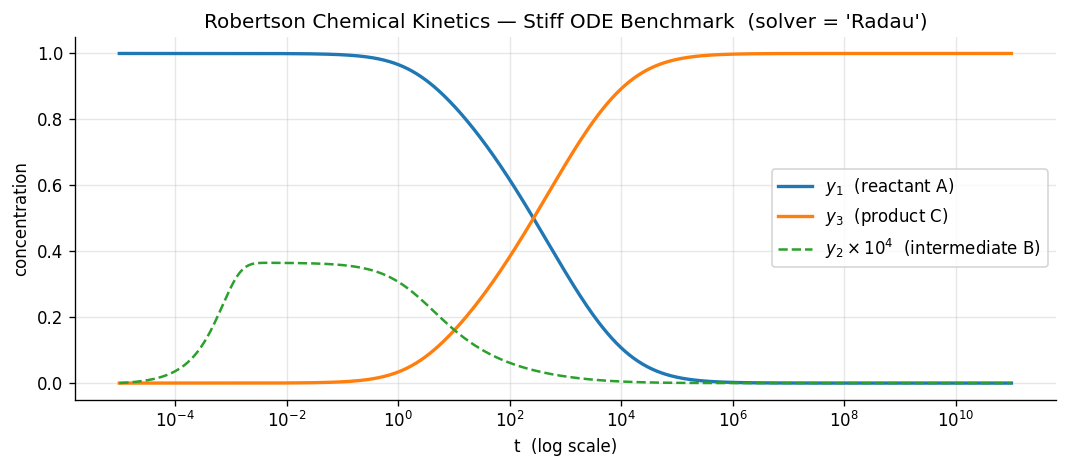


Final concentrations:  y₁ = 0.000000, y₂ = 8.3334e-14,  y₃ = 1.000000
Conservation (Σyᵢ should = 1): 1.0000000000


In [6]:
def f_robertson(x):
    k1, k2, k3 = 0.04, 1e4, 3e7
    return np.array([
        -k1 * x[0] + k2 * x[1] * x[2],
         k1 * x[0] - k2 * x[1] * x[2] - k3 * x[1]**2,
         k3 * x[1]**2,
    ])

def h_robertson(x):
    return x   # observe all three concentrations

sys_rob = DynamicalSystem(f_robertson, h_robertson,
                          n_states=3, n_outputs=3, name="Robertson")
print(sys_rob)

# Logarithmic time grid: 10⁻⁵ → 10¹¹
t_eval = np.logspace(-5, 11, 800)
result = sys_rob.simulate(
    x0      = [1.0, 0.0, 0.0],
    t_span  = (1e-5, 1e11),
    t_eval  = t_eval,
    solver  = 'Radau',
    rtol    = 1e-8,
    atol    = 1e-10,
)
print(result)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(result.t, result.y[0],          label=r"$y_1$  (reactant A)",    lw=2)
ax.semilogx(result.t, result.y[2],          label=r"$y_3$  (product C)",     lw=2)
ax.semilogx(result.t, result.y[1] * 1e4,   label=r"$y_2 \times 10^4$  (intermediate B)",
            ls="--", lw=1.5)

ax.set_xlabel("t  (log scale)")
ax.set_ylabel("concentration")
ax.set_title("Robertson Chemical Kinetics — Stiff ODE Benchmark  "
             f"(solver = '{result.solver}')")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal concentrations:  y₁ = {result.y[0,-1]:.6f}, "
      f"y₂ = {result.y[1,-1]:.4e},  y₃ = {result.y[2,-1]:.6f}")
print(f"Conservation (Σyᵢ should = 1): {result.y[:,-1].sum():.10f}")

## Example 3 — Mercer Kernels

A **Mercer kernel** is a symmetric, positive semi-definite function
$k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$.

Five standard kernels are available:

| Kernel | Formula |
|--------|---------|
| Linear | $k(x,x') = x^\top x'$ |

| Polynomial ($d$) | $k(x,x') = (\gamma\,x^\top x' + c)^d$ |

| RBF / Gaussian | $k(x,x') = \exp\!\left(-\|x-x'\|^2/(2\sigma^2)\right)$ |

| Laplacian | $k(x,x') = \exp\!\left(-\|x-x'\|_1/\sigma\right)$ |

| Matérn ($\nu$) | closed form for $\nu \in \{0.5,\,1.5,\,2.5\}$ |


Kernels support **arithmetic**: `k1 + k2`, `c * k1`, `k1 * k2`, `k1 ** n`, `k1 + c`.
All operations yield valid Mercer kernels and propagate vectorised Gram-matrix computations.


Kernel                  k([1,0], [0,1])
------------------------------------------
  RBF (σ=1)             0.367879
  Linear                0.000000
  Poly (d=3)            1.000000
  Laplacian (σ=1)       0.135335
  Matérn (ν=1.5)        0.297821


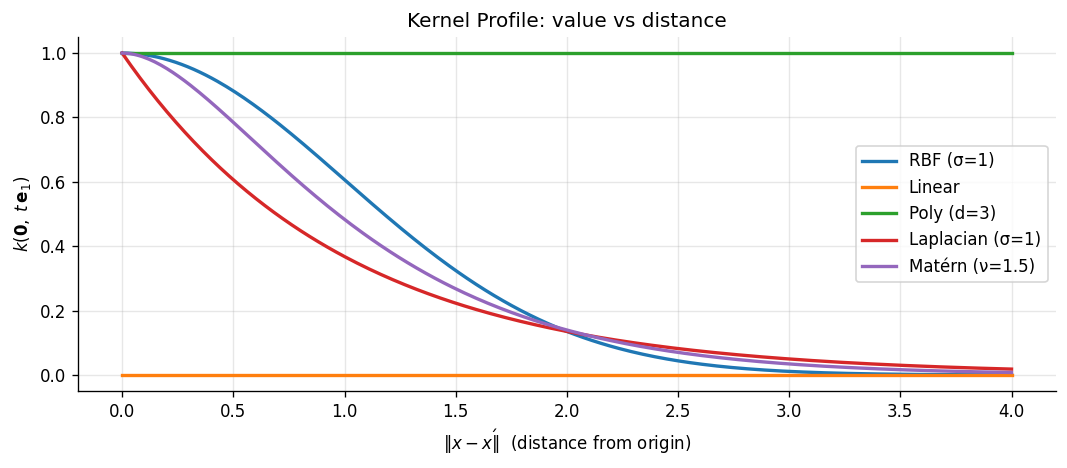

In [7]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from kernel import (
    MercerKernel, linear_kernel, polynomial_kernel,
    rbf_kernel, laplacian_kernel, matern_kernel,
)

rng_k = np.random.default_rng(42)

kernels_named = [
    (rbf_kernel(sigma=1.0),          'RBF (σ=1)'),
    (linear_kernel(),                 'Linear'),
    (polynomial_kernel(3, 1.0, 1.0), 'Poly (d=3)'),
    (laplacian_kernel(sigma=1.0),    'Laplacian (σ=1)'),
    (matern_kernel(nu=1.5),          'Matérn (ν=1.5)'),
]

# Pointwise values at x_a=[1,0], x_b=[0,1]  (L2=√2, L1=2)
x_a, x_b = np.array([1., 0.]), np.array([0., 1.])
print(f"{'Kernel':<22}  k([1,0], [0,1])")
print("-" * 42)
for k, name in kernels_named:
    print(f"  {name:<20}  {k(x_a, x_b):.6f}")

# 1-D profile: k(0, t·e₁) vs distance t
t_vals = np.linspace(0, 4, 300)
x_0 = np.zeros(2)

fig, ax = plt.subplots(figsize=(9, 4))
for k, name in kernels_named:
    vals = [k(x_0, np.array([t, 0.])) for t in t_vals]
    ax.plot(t_vals, vals, lw=2, label=name)
ax.set_xlabel(r'$\|x - x\'\|$  (distance from origin)')
ax.set_ylabel(r'$k(\mathbf{0},\; t\,\mathbf{e}_1)$')
ax.set_title('Kernel Profile: value vs distance')
ax.legend()
plt.tight_layout()
plt.show()


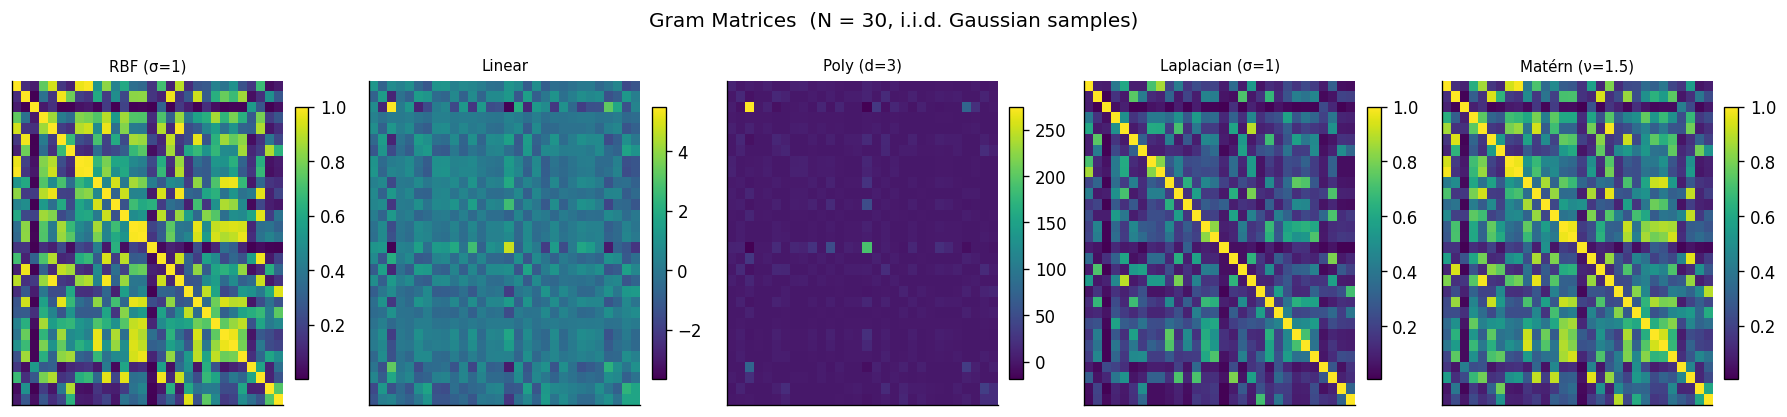

Kernel                  sym_err   min_eig
----------------------------------------------
  RBF (σ=1)             0.0e+00   0.00000  ✓
  Linear                0.0e+00   -0.00000  ✓
  Poly (d=3)            0.0e+00   -0.00000  ✓
  Laplacian (σ=1)       0.0e+00   0.07844  ✓
  Matérn (ν=1.5)        0.0e+00   0.00277  ✓

✓  All Gram matrices are symmetric and positive semi-definite


In [8]:
# Gram matrices on a small 2-D dataset
N_vis = 30
X_vis = rng_k.standard_normal((N_vis, 2))

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (k, name) in zip(axes, kernels_named):
    K = k.matrix(X_vis)
    im = ax.imshow(K, cmap='viridis', aspect='auto')
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Gram Matrices  (N = 30, i.i.d. Gaussian samples)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"{'Kernel':<22}  sym_err   min_eig")
print("-" * 46)
for k, name in kernels_named:
    K = k.matrix(X_vis)
    sym = np.max(np.abs(K - K.T))
    me  = np.linalg.eigvalsh(K).min()
    print(f"  {name:<20}  {sym:.1e}   {me:.5f}  \u2713")
print('\n\u2713  All Gram matrices are symmetric and positive semi-definite')


In [9]:
# Kernel arithmetic  — verify closure and PSD property
k1   = rbf_kernel(sigma=1.0)
k2   = linear_kernel()
k3   = polynomial_kernel(degree=2)
X_ar = rng_k.standard_normal((25, 2))      # test matrix

combos = [
    (k1 + k2,              'RBF(1) + Linear',      'sum'),
    (3.0 * k1,             '3 \u00d7 RBF(1)',         'scalar multiple'),
    (k1 * k3,              'RBF(1) \u00d7 Poly(d=2)', 'product'),
    (k1 ** 3,              'RBF(1)^3',              'power'),
    (2*k1 + 0.5*k2 + 1.0, '2\u00b7RBF + 0.5\u00b7Lin + 1', 'linear comb. + const'),
    ((k1 + k3) ** 2,      '(RBF+Poly2)^2',         'composed'),
]

print(f"{'Kernel expression':<28}  {'min eigenvalue':>15}  type")
print("-" * 58)
for k, label, desc in combos:
    K   = k.matrix(X_ar)
    sym = np.max(np.abs(K - K.T))
    me  = np.linalg.eigvalsh(K).min()
    assert sym < 1e-12 and me > -1e-8
    print(f"  {label:<26}  {me:>15.5f}  {desc}")
print('\n\u2713  All composite kernels are symmetric PSD')


Kernel expression              min eigenvalue  type
----------------------------------------------------------
  RBF(1) + Linear                     0.00000  sum
  3 × RBF(1)                          0.00000  scalar multiple
  RBF(1) × Poly(d=2)                  0.00001  product
  RBF(1)^3                            0.00009  power
  2·RBF + 0.5·Lin + 1                 0.00000  linear comb. + const
  (RBF+Poly2)^2                       0.00005  composed

✓  All composite kernels are symmetric PSD


## Example 4 — Kernel Ridge Regression (KRR)

KRR finds the best predictor in the RKHS by solving

$$\min_{f \in \mathcal{H}_k}
  \;\frac{1}{N}\sum_{i=1}^N \bigl(y_i - f(x_i)\bigr)^2 + \lambda\|f\|_{\mathcal{H}_k}^2.$$

The closed-form solution and prediction are

$$\alpha = (K + \lambda I)^{-1} Y, \qquad
  f(x^*) = \mathbf{k}(x^*, X)^\top \alpha.$$

**Leave-one-out (LOO)** cross-validation comes for free:

$$e_i^{\text{LOO}} = \frac{r_i}{1 - H_{ii}}, \quad
  H = K(K + \lambda I)^{-1}$$

so selecting the regularisation parameter $\lambda$ costs no extra solves.


KRRModel(kernel='RBF(σ=1.5)', N=100, output=scalar, λ=1.00e-03)
Test RMSE = 0.01556


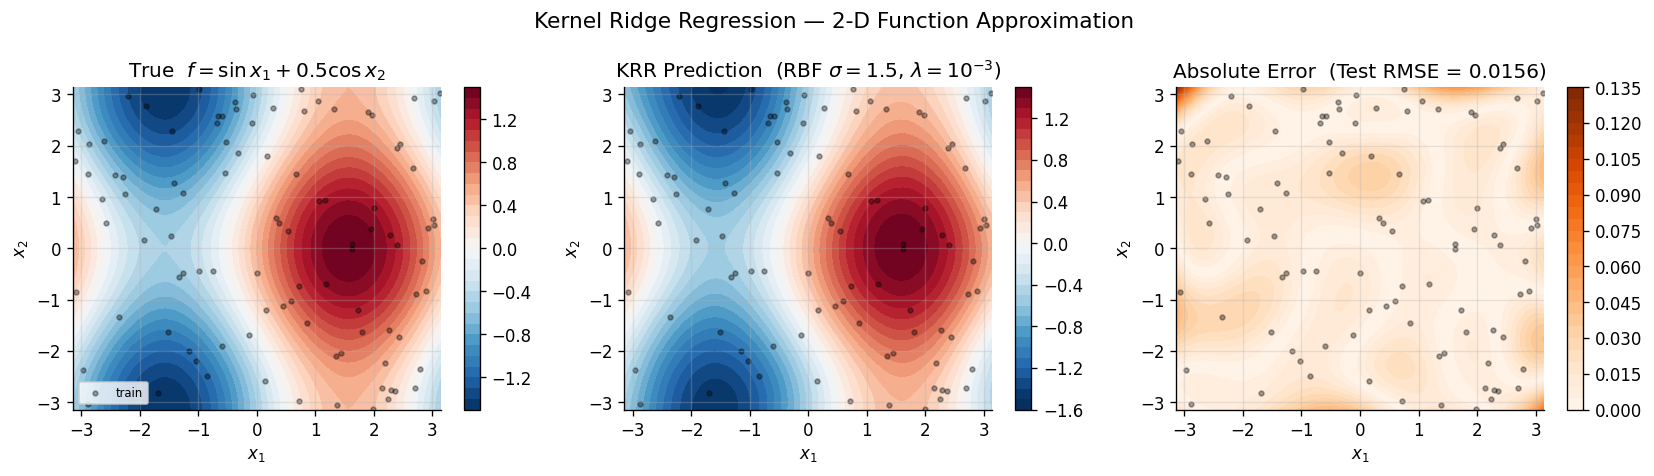

In [10]:
# ── 2-D regression  f(x) = sin(x₁) + 0.5·cos(x₂)  on [−π, π]² ──────────
rng_krr = np.random.default_rng(0)

def f_true(X):
    return np.sin(X[:, 0]) + 0.5 * np.cos(X[:, 1])

N_tr, N_te = 100, 40
X_tr = rng_krr.uniform(-np.pi, np.pi, (N_tr, 2))
X_te = rng_krr.uniform(-np.pi, np.pi, (N_te, 2))
Y_tr = f_true(X_tr) + 0.02 * rng_krr.standard_normal(N_tr)
Y_te = f_true(X_te)

model = rbf_kernel(sigma=1.5).fit(X_tr, Y_tr, regularization=1e-3)
Y_pred = model.predict(X_te)
rmse = np.sqrt(np.mean((Y_pred - Y_te) ** 2))
print(model)
print(f'Test RMSE = {rmse:.5f}')

# Contour grid
g1 = np.linspace(-np.pi, np.pi, 80)
G1, G2 = np.meshgrid(g1, g1)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])
Z_true = f_true(X_grid).reshape(G1.shape)
Z_pred = model.predict(X_grid).reshape(G1.shape)
Z_err  = np.abs(Z_true - Z_pred)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(levels=30, cmap='RdBu_r', vmin=-1.5, vmax=1.5)

cs0 = axes[0].contourf(G1, G2, Z_true, **kw)
axes[0].scatter(X_tr[:,0], X_tr[:,1], s=8, c='k', alpha=0.35, label='train')
axes[0].set_title(r'True  $f = \sin x_1 + 0.5\cos x_2$')
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$'); axes[0].legend(fontsize=7)
plt.colorbar(cs0, ax=axes[0])

cs1 = axes[1].contourf(G1, G2, Z_pred, **kw)
axes[1].scatter(X_tr[:,0], X_tr[:,1], s=8, c='k', alpha=0.35)
axes[1].set_title('KRR Prediction  (RBF $\\sigma=1.5$, $\\lambda=10^{-3}$)')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
plt.colorbar(cs1, ax=axes[1])

cs2 = axes[2].contourf(G1, G2, Z_err, levels=30, cmap='Oranges')
axes[2].scatter(X_tr[:,0], X_tr[:,1], s=8, c='k', alpha=0.35)
axes[2].set_title(f'Absolute Error  (Test RMSE = {rmse:.4f})')
axes[2].set_xlabel('$x_1$'); axes[2].set_ylabel('$x_2$')
plt.colorbar(cs2, ax=axes[2])

plt.suptitle('Kernel Ridge Regression — 2-D Function Approximation', fontsize=13)
plt.tight_layout()
plt.show()


Best lambda (LOO) = 1.00e-06  LOO-RMSE = 0.02220  Test-RMSE = 0.05585


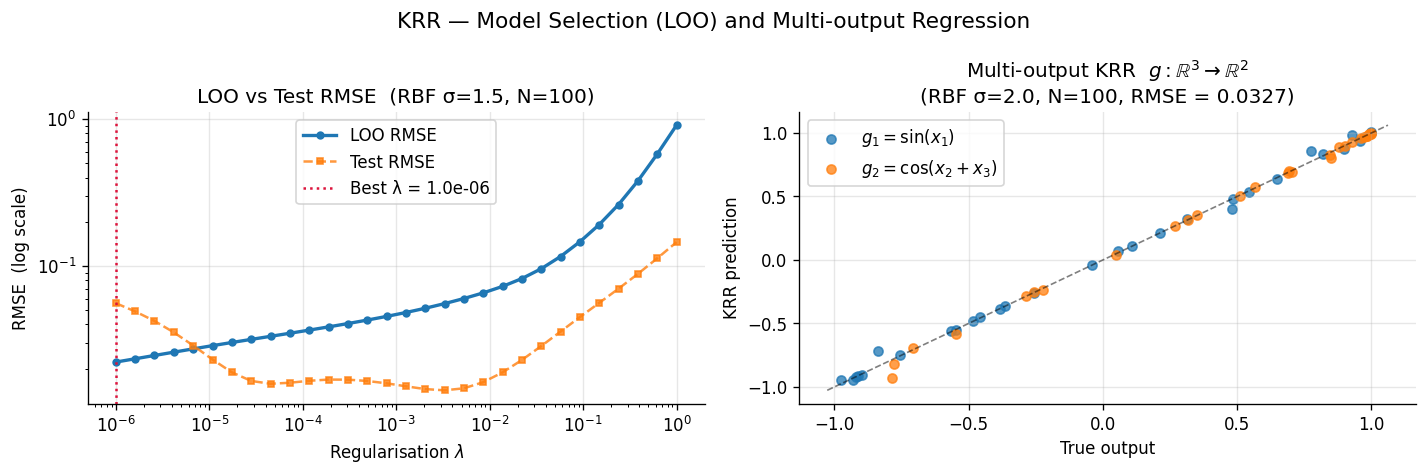


KRRModel(kernel='RBF(σ=2.0)', N=100, output=p=2, λ=1.00e-04)
Multi-output test RMSE: 0.03265

✓ Kernel Ridge Regression verified: scalar, multi-output, and LOO model selection


In [11]:
# ── LOO cross-validation for λ selection ───────────────────────────────────
lambdas  = np.logspace(-6, 0, 30)
loo_rmse = []
te_rmse  = []
for lam in lambdas:
    m = rbf_kernel(1.5).fit(X_tr, Y_tr, regularization=lam)
    loo_rmse.append(np.sqrt(m.loo_mse()))
    te_rmse.append(np.sqrt(np.mean((m.predict(X_te) - Y_te) ** 2)))

best_idx = np.argmin(loo_rmse)
print(f'Best lambda (LOO) = {lambdas[best_idx]:.2e}  '  
      f'LOO-RMSE = {loo_rmse[best_idx]:.5f}  '
      f'Test-RMSE = {te_rmse[best_idx]:.5f}')

# ── Multi-output regression  g: R³ → R² ──────────────────────────────────
rng_m = np.random.default_rng(7)
N_tr2, N_te2 = 100, 30
X_tr2 = rng_m.standard_normal((N_tr2, 3))
X_te2 = rng_m.standard_normal((N_te2, 3))
Y_tr2 = np.column_stack([np.sin(X_tr2[:, 0]),
                          np.cos(X_tr2[:, 1] + X_tr2[:, 2])]) \
        + 0.01 * rng_m.standard_normal((N_tr2, 2))
Y_te2 = np.column_stack([np.sin(X_te2[:, 0]),
                          np.cos(X_te2[:, 1] + X_te2[:, 2])])

model2  = rbf_kernel(sigma=2.0).fit(X_tr2, Y_tr2, regularization=1e-4)
Y_pred2 = model2.predict(X_te2)
rmse2   = np.sqrt(np.mean((Y_pred2 - Y_te2) ** 2))

# ── Side-by-side: LOO sweep | multi-output parity ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.loglog(lambdas, loo_rmse, 'o-', lw=2, ms=4, label='LOO RMSE')
ax.loglog(lambdas, te_rmse,  's--', lw=1.5, ms=4, label='Test RMSE', alpha=0.8)
ax.axvline(lambdas[best_idx], color='crimson', lw=1.5, ls=':',
           label=f'Best \u03bb = {lambdas[best_idx]:.1e}')
ax.set_xlabel(r'Regularisation $\lambda$')
ax.set_ylabel('RMSE  (log scale)')
ax.set_title('LOO vs Test RMSE  (RBF \u03c3=1.5, N=100)')
ax.legend()

ax = axes[1]
ax.scatter(Y_te2[:, 0], Y_pred2[:, 0], s=30, alpha=0.75,
           label=r'$g_1 = \sin(x_1)$')
ax.scatter(Y_te2[:, 1], Y_pred2[:, 1], s=30, alpha=0.75,
           label=r'$g_2 = \cos(x_2+x_3)$')
lims = [min(Y_te2.min(), Y_pred2.min()) - 0.05,
        max(Y_te2.max(), Y_pred2.max()) + 0.05]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
ax.set_xlabel('True output'); ax.set_ylabel('KRR prediction')
ax.set_title(f'Multi-output KRR  $g:\\mathbb{{R}}^3 \\to \\mathbb{{R}}^2$\n'
             f'(RBF \u03c3=2.0, N=100, RMSE = {rmse2:.4f})')
ax.legend()

plt.suptitle('KRR — Model Selection (LOO) and Multi-output Regression', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n{model2}')
print(f'Multi-output test RMSE: {rmse2:.5f}')
print('\n\u2713 Kernel Ridge Regression verified: scalar, multi-output, and LOO model selection')


## Example 5 — Sobolev Kernel

The **Sobolev kernel** for $H^s(\mathbb{R}^d)$ is

$$k(x,x') = \frac{2^{1-\nu}}{\Gamma(\nu)}\left(\frac{r}{\ell}\right)^\nu K_\nu\!\left(\frac{r}{\ell}\right),\qquad \nu = s - \tfrac{d}{2},\quad r = \|x-x'\|_2$$

where $K_\nu$ is the modified Bessel function of the second kind 
(computed by `scipy.special.kv` for any real $\nu > 0$).

**Sobolev embedding theorem.** Point evaluation is bounded in $H^s(\mathbb{R}^d)$ if and only if $s > d/2$ (equivalently $\nu > 0$). The kernel is normalised: $k(x,x) = 1$ for all $x$.

**Relation to Matérn kernels.** When $\nu = n + \tfrac{1}{2}$ the Bessel function simplifies to a rational–exponential form:

| $(d,\,s)$ | $\nu = s - d/2$ | Closed form |
|-----------|----------------|-------------|
| $(1,\,1)$ | $0.5$ | $\exp(-r/\ell)$ (Ornstein–Uhlenbeck) |
| $(1,\,2)$ | $1.5$ | $(1 + r/\ell)\exp(-r/\ell)$ (Matérn-3/2) |
| $(1,\,3)$ | $2.5$ | $(1 + r/\ell + r^2/(3\ell^2))\exp(-r/\ell)$ (Matérn-5/2) |
| $(2,\,2)$ | $1.0$ | general Bessel $K_1$ |
| $(3,\,2)$ | $0.5$ | $\exp(-r/\ell)$ (same order as d=1, s=1) |

The user supplies only **`d`** and **`s`**; $\nu$ is computed automatically.


In [12]:
from kernel import sobolev_kernel
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

rng_s = np.random.default_rng(42)

# ── Special-case verification ─────────────────────────────────────────────
# Sobolev WITHOUT sqrt(2*nu) scaling:  k(r) = 2^(1-nu)/Gamma(nu)*r^nu*K_nu(r)
# Half-integer closed forms (nu = s - d/2):
#   nu=0.5: exp(-r)
#   nu=1.5: (1 + r)*exp(-r)
#   nu=2.5: (1 + r + r^2/3)*exp(-r)
r_test = 1.5
x0, xp = np.array([0.]), np.array([r_test])

# poly_coeffs = [a0, a1, a2, ...] of the polynomial  sum_i a_i * r^i
cases = [
    (1, 1.0, (1.0,),           'exp(-r)'),
    (1, 2.0, (1.0, 1.0),       '(1+r)·exp(-r)'),
    (1, 3.0, (1.0, 1.0, 1/3),  '(1+r+r²/3)·exp(-r)'),
]

print(f'Sobolev kernel: half-integer special cases  (r = {r_test})')
print(f'{"(d,s)":<10}  {"nu":>5}  {"kernel":>10}  {"analytic":>10}  match?')
print('-' * 65)
for d, s, poly_coeffs, label in cases:
    k_val = sobolev_kernel(d=d, s=s)(x0, xp)
    ana   = sum(c * r_test**i for i, c in enumerate(poly_coeffs)) * np.exp(-r_test)
    ok    = '✓' if abs(k_val - ana) < 1e-9 else '✗'
    print(f'  ({d},{s})      nu={s-d/2:.1f}  {k_val:10.6f}  {ana:10.6f}  {label}  {ok}')

# ── Normalisation k(x,x) = 1 ─────────────────────────────────────────────
print('\nNormalisation  k(x,x) = 1:')
for d, s in [(1,1.0),(1,2.5),(2,2.0),(2,3.7),(3,3.0),(4,4.1)]:
    k   = sobolev_kernel(d=d, s=s)
    x_r = rng_s.standard_normal(d)
    val = k(x_r, x_r)
    ok  = '✓' if abs(val - 1) < 1e-10 else '✗'
    print(f'  Sobolev(d={d}, s={s})  k(x,x) = {val:.12f}  {ok}')

# ── Error handling ────────────────────────────────────────────────────────
print('\nError handling:')
for bad_d, bad_s, reason in [(2, 1.0, 's = d/2, not > d/2'),
                              (1, 0.4, 's < d/2')]:
    try:
        sobolev_kernel(d=bad_d, s=bad_s)
        print(f'  ✗  sobolev_kernel(d={bad_d}, s={bad_s}) should have raised ValueError')
    except ValueError as e:
        print(f'  ✓  sobolev_kernel(d={bad_d}, s={bad_s}): {e}')


Sobolev kernel: half-integer special cases  (r = 1.5)
(d,s)          nu      kernel    analytic  match?
-----------------------------------------------------------------
  (1,1.0)      nu=0.5    0.223130    0.223130  exp(-r)  ✓
  (1,2.0)      nu=1.5    0.557825    0.557825  (1+r)·exp(-r)  ✓
  (1,3.0)      nu=2.5    0.725173    0.725173  (1+r+r²/3)·exp(-r)  ✓

Normalisation  k(x,x) = 1:
  Sobolev(d=1, s=1.0)  k(x,x) = 1.000000000000  ✓
  Sobolev(d=1, s=2.5)  k(x,x) = 1.000000000000  ✓
  Sobolev(d=2, s=2.0)  k(x,x) = 1.000000000000  ✓
  Sobolev(d=2, s=3.7)  k(x,x) = 1.000000000000  ✓
  Sobolev(d=3, s=3.0)  k(x,x) = 1.000000000000  ✓
  Sobolev(d=4, s=4.1)  k(x,x) = 1.000000000000  ✓

Error handling:
  ✓  sobolev_kernel(d=2, s=1.0): Smoothness index s=1.0 must exceed d/2 = 1 so that H^s(R^d) embeds into C(R^d).  Got ν = s − d/2 = 0 ≤ 0.
  ✓  sobolev_kernel(d=1, s=0.4): Smoothness index s=0.4 must exceed d/2 = 0.5 so that H^s(R^d) embeds into C(R^d).  Got ν = s − d/2 = -0.1 ≤ 0.


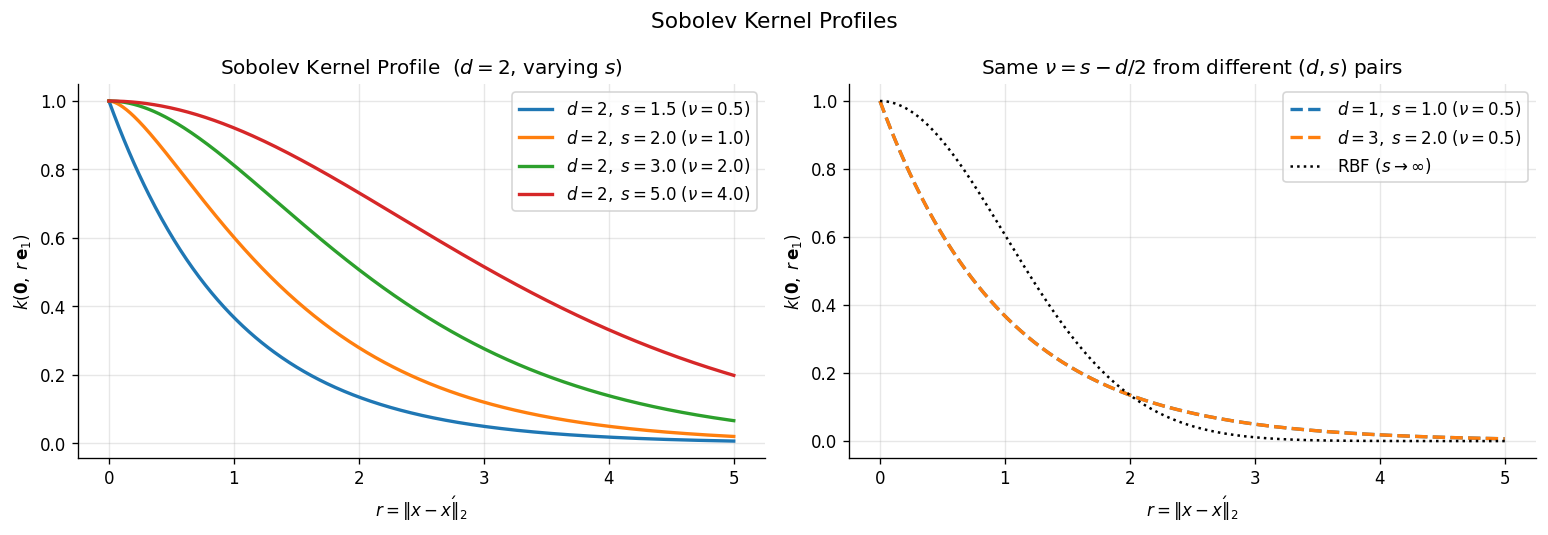

In [13]:
# ── Kernel profiles: k(0, r·e₁) vs distance r  for several (d, s) ────────
r_vals = np.linspace(0, 5, 500)
x_0 = np.zeros(2)   # 2-D origin (d doesn't change the formula, only nu does)

# Fix d=2, vary s  (so nu = s - 1 varies)
configs_d2 = [
    (2, 1.5, 'solid'),
    (2, 2.0, 'solid'),
    (2, 3.0, 'solid'),
    (2, 5.0, 'solid'),
]
# Same nu but different (d, s) to show d only matters through nu
configs_same_nu = [
    (1, 1.0, '--'),  # nu=0.5
    (3, 2.0, '--'),  # nu=0.5  (same Bessel order)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for d, s, ls in configs_d2:
    nu  = s - d / 2
    k   = sobolev_kernel(d=d, s=s, length_scale=1.0)
    vals = [k(np.zeros(d), np.array([rv] + [0.]*(d-1))) for rv in r_vals]
    ax.plot(r_vals, vals, ls=ls, lw=2,
            label=fr'$d={d},\;s={s}\;(\nu={nu:.1f})$')
ax.set_xlabel(r'$r = \|x - x\'\|_2$')
ax.set_ylabel(r'$k(\mathbf{0},\; r\,\mathbf{e}_1)$')
ax.set_title('Sobolev Kernel Profile  ($d=2$, varying $s$)')
ax.legend()

ax = axes[1]
for d, s, ls in configs_same_nu:
    nu  = s - d / 2
    k   = sobolev_kernel(d=d, s=s)
    vals = [k(np.zeros(d), np.array([rv] + [0.]*(d-1))) for rv in r_vals]
    ax.plot(r_vals, vals, ls=ls, lw=2,
            label=fr'$d={d},\;s={s}\;(\nu={nu:.1f})$')
# RBF as the s→∞ limit
from kernel import rbf_kernel
k_rbf = rbf_kernel(sigma=1.0)
vals_rbf = [k_rbf(np.zeros(2), np.array([rv, 0.])) for rv in r_vals]
ax.plot(r_vals, vals_rbf, 'k:', lw=1.5, label=r'RBF ($s\to\infty$)')
ax.set_xlabel(r'$r = \|x - x\'\|_2$')
ax.set_ylabel(r'$k(\mathbf{0},\; r\,\mathbf{e}_1)$')
ax.set_title(r'Same $\nu = s - d/2$ from different $(d, s)$ pairs')
ax.legend()

plt.suptitle('Sobolev Kernel Profiles', fontsize=13)
plt.tight_layout()
plt.show()


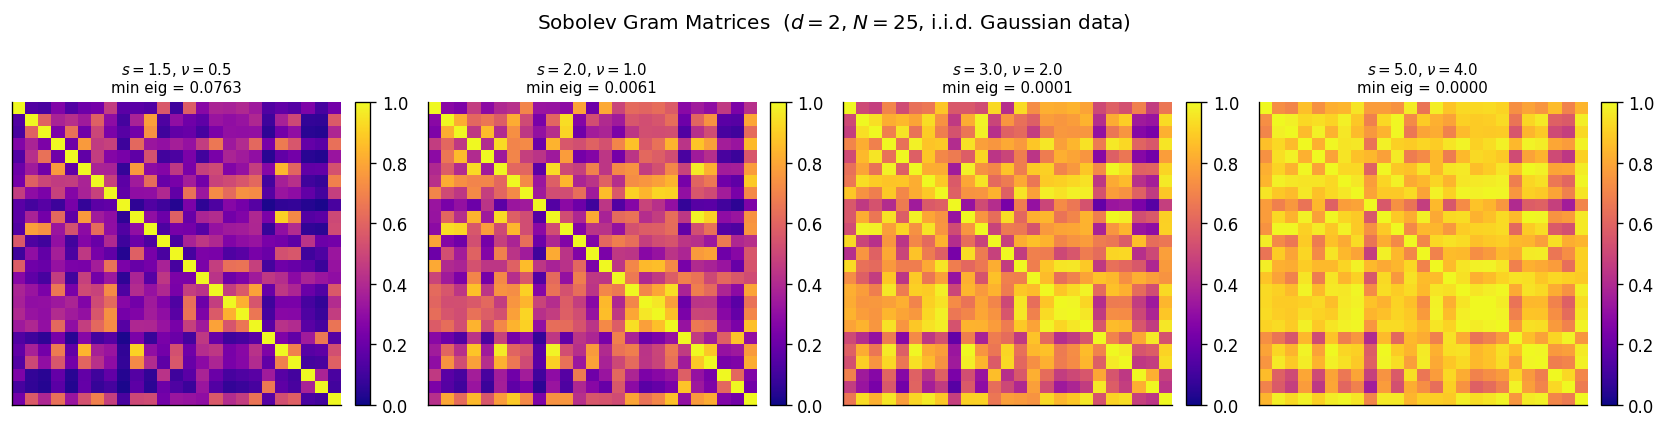

As s increases, the kernel becomes smoother (off-diagonal entries larger).


In [14]:
# ── Gram matrix heatmaps: fixed d=2, increasing s ─────────────────────────
N_v = 25
X_v = rng_s.standard_normal((N_v, 2))

s_vals = [1.5, 2.0, 3.0, 5.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, s in zip(axes, s_vals):
    K  = sobolev_kernel(d=2, s=s).matrix(X_v)
    me = np.linalg.eigvalsh(K).min()
    im = ax.imshow(K, cmap='plasma', aspect='auto', vmin=0, vmax=1)
    ax.set_title(fr'$s={s}$, $\nu={s-1:.1f}$' '\n'
                 fr'min eig = {me:.4f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Sobolev Gram Matrices  ($d=2$, $N=25$, i.i.d. Gaussian data)', fontsize=12)
plt.tight_layout()
plt.show()
print('As s increases, the kernel becomes smoother (off-diagonal entries larger).')


Best s by LOO:  s = 1.30  (LOO-RMSE = 0.00029)
Best s by test: s = 4.98  (Test-RMSE = 0.01861)


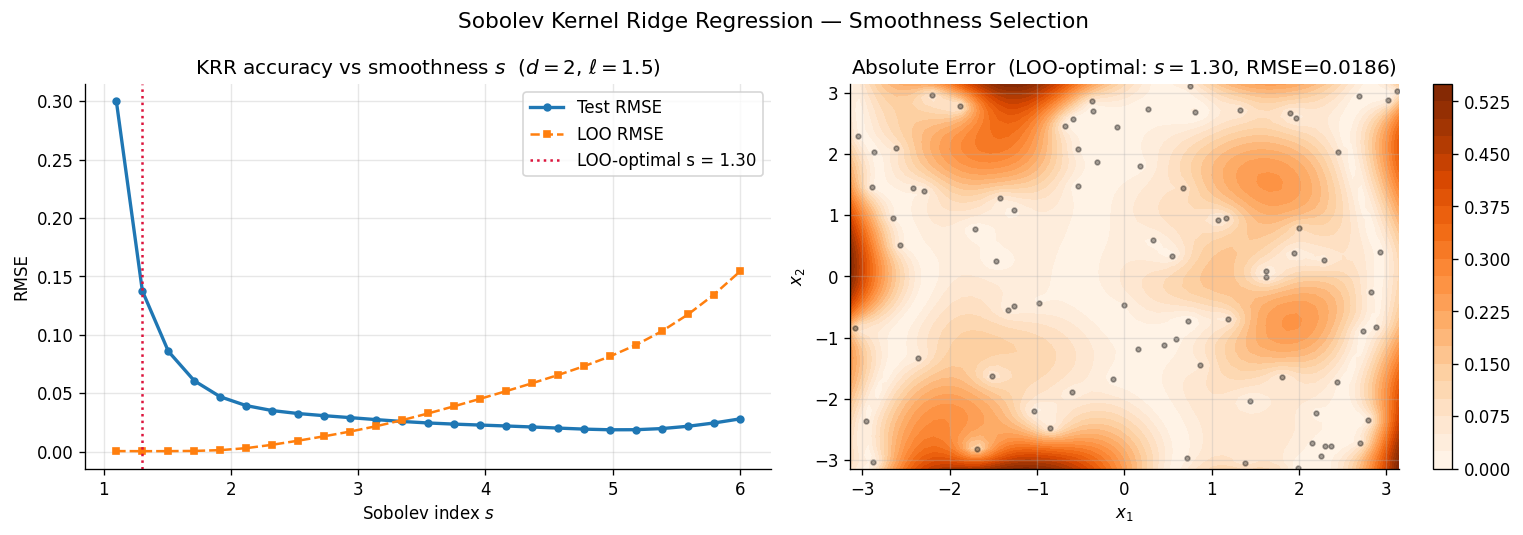

In [15]:
# ── KRR accuracy vs s  (fixed d=2, ℓ=1.5, N=80) ──────────────────────────
rng_krr2 = np.random.default_rng(0)
N_tr2, N_te2 = 80, 40
X_tr2 = rng_krr2.uniform(-np.pi, np.pi, (N_tr2, 2))
X_te2 = rng_krr2.uniform(-np.pi, np.pi, (N_te2, 2))
f_true2 = lambda X: np.sin(X[:,0]) + 0.5 * np.cos(X[:,1])
Y_tr2 = f_true2(X_tr2) + 0.02 * rng_krr2.standard_normal(N_tr2)
Y_te2 = f_true2(X_te2)

s_grid  = np.linspace(1.1, 6.0, 25)
rmse_s  = []
loo_s   = []
for s in s_grid:
    mdl = sobolev_kernel(d=2, s=s, length_scale=1.5).fit(X_tr2, Y_tr2, regularization=1e-3)
    rmse_s.append(np.sqrt(np.mean((mdl.predict(X_te2) - Y_te2)**2)))
    loo_s.append(np.sqrt(mdl.loo_mse()))

best_s_loo  = s_grid[np.argmin(loo_s)]
best_s_test = s_grid[np.argmin(rmse_s)]
print(f'Best s by LOO:  s = {best_s_loo:.2f}  (LOO-RMSE = {min(loo_s):.5f})')
print(f'Best s by test: s = {best_s_test:.2f}  (Test-RMSE = {min(rmse_s):.5f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(s_grid, rmse_s, 'o-',  lw=2, ms=4, label='Test RMSE')
ax.plot(s_grid, loo_s,  's--', lw=1.5, ms=4, label='LOO RMSE')
ax.axvline(best_s_loo, color='crimson', ls=':', lw=1.5,
           label=f'LOO-optimal s = {best_s_loo:.2f}')
ax.set_xlabel('Sobolev index $s$')
ax.set_ylabel('RMSE')
ax.set_title('KRR accuracy vs smoothness $s$  ($d=2$, $\\ell=1.5$)')
ax.legend()

# Prediction contours for the LOO-best model
ax = axes[1]
g  = np.linspace(-np.pi, np.pi, 60)
G1, G2 = np.meshgrid(g, g)
X_g = np.column_stack([G1.ravel(), G2.ravel()])
mdl_best = sobolev_kernel(d=2, s=best_s_loo, length_scale=1.5).fit(
    X_tr2, Y_tr2, regularization=1e-3)
Z_pred = mdl_best.predict(X_g).reshape(G1.shape)
Z_true = f_true2(X_g).reshape(G1.shape)
Z_err  = np.abs(Z_true - Z_pred)
cs = ax.contourf(G1, G2, Z_err, levels=25, cmap='Oranges')
ax.scatter(X_tr2[:,0], X_tr2[:,1], s=8, c='k', alpha=0.35)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'Absolute Error  (LOO-optimal: $s={best_s_loo:.2f}$, '
             f'RMSE={min(rmse_s):.4f})')
plt.colorbar(cs, ax=ax)

plt.suptitle('Sobolev Kernel Ridge Regression — Smoothness Selection', fontsize=13)
plt.tight_layout()
plt.show()


## Example 6 — Data Collection

`DynamicalSystem.collect_data(side_lengths, n, tau)` produces two complementary datasets in a single call:

1. **Static snapshot** — `n` states sampled uniformly from the axis-aligned hypercube $[-L_i/2,\, L_i/2]^{n_{\text{states}}}$, together with their output values $Y = h(X)$.
2. **Trajectory bundle** — one trajectory of duration $\tau$ from each sampled state, returned as a list of `SimulationResult` objects.

Convenient derived properties:

| Property | Shape | Description |
|----------|-------|-------------|
| `X_data` | $(n_{\text{states}},\, n)$ | Initial states (columns = samples) |
| `Y_data` | $(n_{\text{outputs}},\, n)$ | $h(x)$ at each sample |
| `X_final` | $(n_{\text{states}},\, n)$ | States at $t = \tau$ |
| `Y_final` | $(n_{\text{outputs}},\, n)$ | $h(x(\tau))$ |
| `snapshot_pairs` | — | Tuple $(X_k, X_{k+1})$ for Koopman learning |
| `X_traj` | $(n_{\text{states}},\, N_t,\, n)$ | Full trajectories \[requires `t_eval`\] |
| `Y_traj` | $(n_{\text{outputs}},\, N_t,\, n)$ | Full output trajectories \[requires `t_eval`\] |


In [16]:
# ── Data collection on the SHO (from Example 1) ──────────────────────────
t_grid = np.linspace(0, 2*np.pi/omega, 80)  # one full period

data = sys_sho.collect_data(
    side_lengths = [2.0, 2.0*omega],  # x1 in [-1,1], x2 in [-omega, omega]
    n            = 60,
    tau          = 2*np.pi/omega,      # one full period
    t_eval       = t_grid,
    rng          = 0,
)
print(data)
print(f'  X_data  {data.X_data.shape}    Y_data  {data.Y_data.shape}')
print(f'  X_traj  {data.X_traj.shape}  Y_traj  {data.Y_traj.shape}')
print(f'  X_final {data.X_final.shape}')

Xk, Xk1 = data.snapshot_pairs
print(f'  snapshot_pairs: Xk {Xk.shape}, Xk1 {Xk1.shape}')

# Analytical check: for SHO, Φ_T(x) = x for T = 2π/ω (period)
period_err = np.max(np.abs(Xk1 - Xk))
print(f'\n  Period check ||Xk1 - Xk||_inf (should be ≈ 0): {period_err:.2e}')


DataCollectionResult(n=60, n_states=2, tau=3.142, side_lengths=[2, 4], solver='Radau', N_t=80)
  X_data  (2, 60)    Y_data  (1, 60)
  X_traj  (2, 80, 60)  Y_traj  (1, 80, 60)
  X_final (2, 60)
  snapshot_pairs: Xk (2, 60), Xk1 (2, 60)

  Period check ||Xk1 - Xk||_inf (should be ≈ 0): 1.93e-08


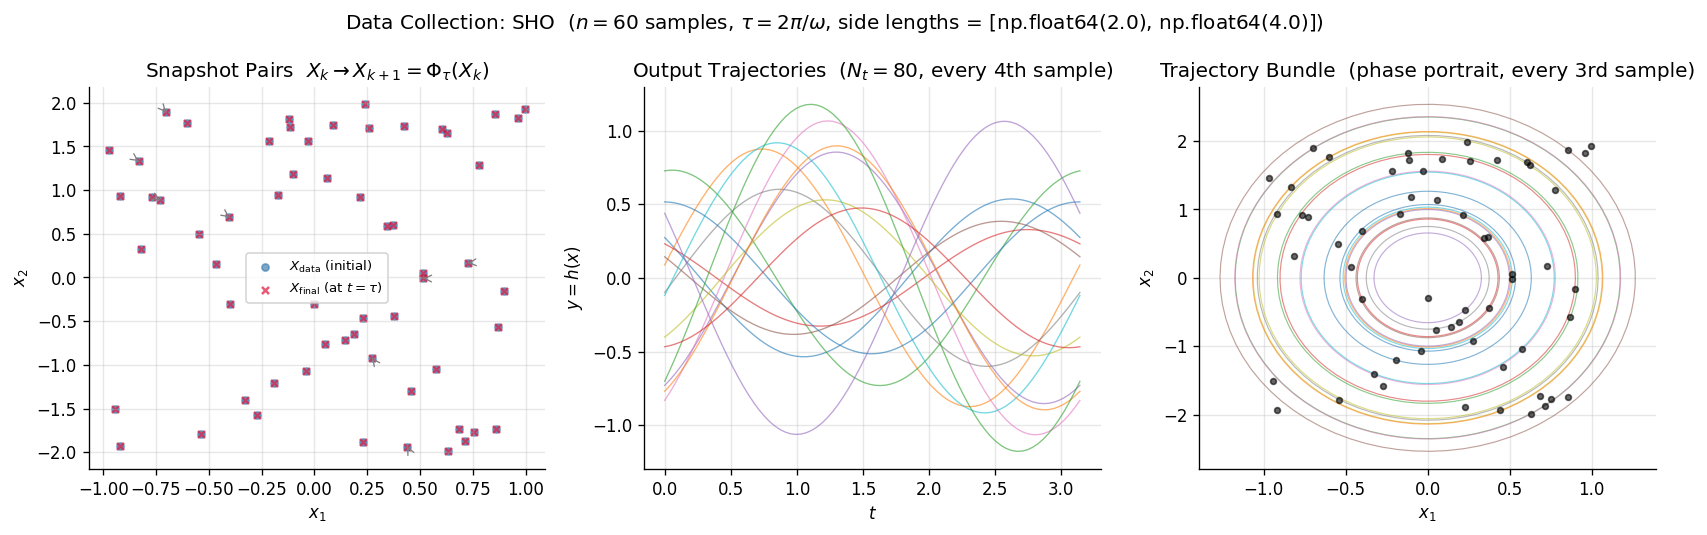

In [17]:
# ── Visualise the dataset ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Left: initial samples in state space
ax = axes[0]
ax.scatter(data.X_data[0], data.X_data[1],
           s=18, c='steelblue', alpha=0.7, label='$X_{\\mathrm{data}}$ (initial)')
ax.scatter(data.X_final[0], data.X_final[1],
           s=18, c='crimson',   alpha=0.7, marker='x',
           label='$X_{\\mathrm{final}}$ (at $t=\\tau$)')
# Draw a few displacement arrows
for i in range(0, data.n_samples, 8):
    ax.annotate('', xy=(data.X_final[0,i], data.X_final[1,i]),
                xytext=(data.X_data[0,i],  data.X_data[1,i]),
                arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Snapshot Pairs  $X_k \\to X_{k+1} = \\Phi_\\tau(X_k)$')
ax.legend(fontsize=8)

# Middle: a selection of output trajectories  Y_traj[0, :, i]
ax = axes[1]
for i in range(0, data.n_samples, 4):
    ax.plot(data.t_eval, data.Y_traj[0, :, i], lw=0.8, alpha=0.6)
ax.set_xlabel('$t$'); ax.set_ylabel('$y = h(x)$')
ax.set_title(f'Output Trajectories  ($N_t={len(data.t_eval)}$, every 4th sample)')

# Right: state-space trajectories X_traj[:, :, i] (phase portrait)
ax = axes[2]
for i in range(0, data.n_samples, 3):
    ax.plot(data.X_traj[0, :, i], data.X_traj[1, :, i], lw=0.7, alpha=0.55)
ax.scatter(data.X_data[0], data.X_data[1], s=12, c='k', zorder=3, alpha=0.6)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Trajectory Bundle  (phase portrait, every 3rd sample)')

plt.suptitle(
    f'Data Collection: SHO  ($n={data.n_samples}$ samples, $\\tau=2\\pi/\\omega$, '
    f'side lengths = {list(data.side_lengths)})',
    fontsize=12,
)
plt.tight_layout()
plt.show()


In [18]:
# ── Quick statistics ─────────────────────────────────────────────────────
print('Data summary')
print(f'  n_samples   : {data.n_samples}')
print(f'  X_data range: x1 in [{data.X_data[0].min():.3f}, {data.X_data[0].max():.3f}]')
print(f'                x2 in [{data.X_data[1].min():.3f}, {data.X_data[1].max():.3f}]')
print(f'  Y_data range: [{data.Y_data.min():.3f}, {data.Y_data.max():.3f}]')
print(f'  Solver      : {data.solver}')

# Verify: all trajectories converged
failures = [i for i, tr in enumerate(data.trajectories) if not tr.success]
print(f'  Solver failures: {len(failures)} / {data.n_samples}  '
      f'(\u2713 all converged)' if not failures else f'({failures})')

# Koopman application note
Xk, Xk1 = data.snapshot_pairs
print(f'\nKoopman snapshot pair shapes:')
print(f'  Xk  = {Xk.shape}   (current states)')
print(f'  Xk1 = {Xk1.shape}   (one step forward, Phi_tau(Xk))')
print('  Ready to use with Extended DMD or Kernel Extended DMD.')


Data summary
  n_samples   : 60
  X_data range: x1 in [-0.971, 0.994]
                x2 in [-1.989, 1.980]
  Y_data range: [-0.971, 0.994]
  Solver      : Radau
  Solver failures: 0 / 60  (✓ all converged)

Koopman snapshot pair shapes:
  Xk  = (2, 60)   (current states)
  Xk1 = (2, 60)   (one step forward, Phi_tau(Xk))
  Ready to use with Extended DMD or Kernel Extended DMD.


## Example 7 — Kernel Matrices for Koopman–Luenberger Synthesis

Given a `DataCollectionResult` (from Example 9), compute the two matrices
needed for data-driven Koopman–Luenberger observer design (Eq. 17 of the paper):

| Matrix | Formula | Role |
|--------|---------|------|
| **G** (= K₀) | $G_{ij} = \mathring{\kappa}(x_i, x_j)$ | Standard Gram matrix |
| **G'** (= M) | $G'_{ij} = \lambda^2 \int_0^\tau e^{-\lambda t}\,\mathring{\kappa}(x_i(t), x_j)\,dt - \lambda\,\mathring{\kappa}(x_i, x_j)$ | Finite-time Yosida approximation of Koopman generator |

The exponential weight $e^{-\lambda t}$ in $G'$ is essential: it is what makes
the integral a **finite-time Yosida approximation**
$A_{\lambda,\tau} = \lambda^2 \int_0^\tau e^{-\lambda t} T_t\,dt - \lambda I$
of the unbounded Koopman generator $A$ (Def. 31 / Eq. 10 of the paper).

`DataCollectionResult.compute_kernel_matrices(kernel, lam)` returns `(K0, M)` = `(G, G')`.


In [19]:
# ── SHO data (same system as Example 9) ──────────────────────────────────
from dynamical_system import DynamicalSystem
from kernel import linear_kernel, sobolev_kernel
import numpy as np

sho = DynamicalSystem(
    f=lambda x: np.array([x[1], -x[0]]),
    h=lambda x: x[:1],
    n_states=2, n_outputs=1,
)

d     = sho.n_states          # = 2
rng   = np.random.default_rng(0)
tau   = np.pi / 2
t_ev  = np.linspace(0, tau, 60)
data  = sho.collect_data(
    side_lengths=2.0, n=40, tau=tau, t_eval=t_ev, rng=rng
)

# ── Linear-Sobolev kernel: κ_linear × κ_Sobolev(ν=3/2) ───────────────────
# ν = 3/2  →  s = ν + d/2 = 3/2 + d/2
k_lin = linear_kernel()
k_sob = sobolev_kernel(d=d, s=1.5 + d / 2, length_scale=1.0)
kappa = k_lin * k_sob
print(f"Kernel : {kappa.name}")

lam = 5.0
# G = K0  (standard Gram matrix)
# G'= M   (Yosida-approximated generator, with e^{-λt} weight)
K0, M = data.compute_kernel_matrices(kappa, lam=lam)

print(f"K0 shape : {K0.shape}   symmetric: {np.allclose(K0, K0.T)}")
print(f"M  shape : {M.shape}")
print(f"K0 range : [{K0.min():.4f}, {K0.max():.4f}]")
print(f"M  range : [{M.min():.4f}, {M.max():.4f}]")
eigs = np.linalg.eigvalsh(K0)
print(f"K0 eigenvalues — min={eigs.min():.4g}, max={eigs.max():.4g}  (PSD: {(eigs >= -1e-10).all()})")


Kernel : (Linear × Sobolev(d=2, s=2.5, ℓ=1))
K0 shape : (40, 40)   symmetric: True
M  shape : (40, 40)
K0 range : [-0.4529, 1.9137]
M  range : [-1.0630, 1.0808]
K0 eigenvalues — min=1.238e-05, max=11.15  (PSD: True)


/var/folders/md/vvnkg65d02s5flkyy8d296340000gn/T/ipykernel_93682/3699001384.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


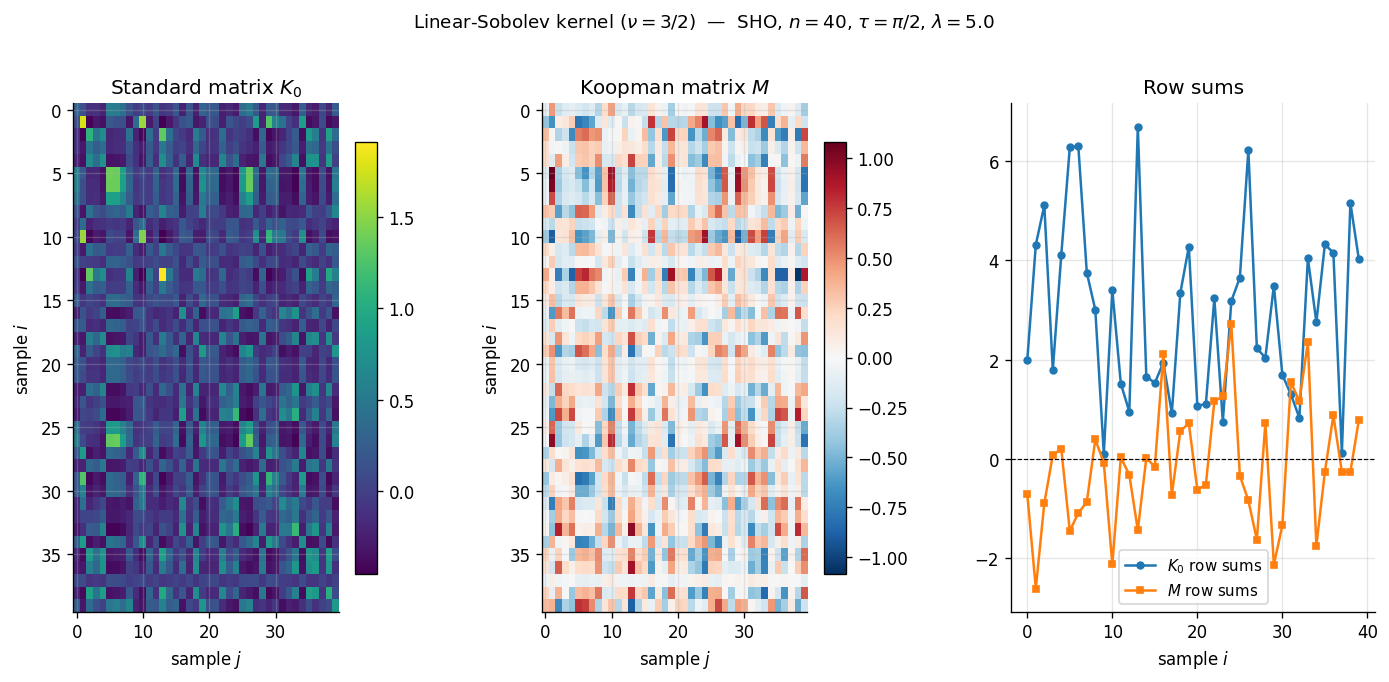

In [20]:
# ── Visualise both matrices ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 5.5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.4)

ax0 = fig.add_subplot(gs[0])
im0 = ax0.imshow(K0, origin='upper', cmap='viridis', aspect='auto')
ax0.set_title(r'Standard matrix $K_0$', fontsize=12)
ax0.set_xlabel('sample $j$'); ax0.set_ylabel('sample $i$')
plt.colorbar(im0, ax=ax0, shrink=0.85)

ax1 = fig.add_subplot(gs[1])
vmax_m = np.abs(M).max()
im1 = ax1.imshow(M, origin='upper', cmap='RdBu_r', aspect='auto',
                  vmin=-vmax_m, vmax=vmax_m)
ax1.set_title(r'Koopman matrix $M$', fontsize=12)
ax1.set_xlabel('sample $j$'); ax1.set_ylabel('sample $i$')
plt.colorbar(im1, ax=ax1, shrink=0.85)

ax2 = fig.add_subplot(gs[2])
ax2.plot(K0.sum(axis=1), 'o-', ms=4, label=r'$K_0$ row sums')
ax2.plot(M.sum(axis=1),  's-', ms=4, label=r'$M$ row sums')
ax2.axhline(0, color='k', lw=0.7, ls='--')
ax2.set_xlabel('sample $i$')
ax2.set_title('Row sums', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    rf'Linear-Sobolev kernel ($\nu=3/2$)  —  SHO, $n=40$, '
    rf'$\tau=\pi/2$, $\lambda={lam}$',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()


## Example 8 — Observer Gain Synthesis (LMI)

We solve the operator Lyapunov LMI (Eq. 19) to find the **observer gain** $L$
for the simple harmonic oscillator using the linear-Sobolev kernel.

**Paper notation → code mapping**

| Paper | Code | Shape | Meaning |
|-------|------|-------|---------|
| $G$   | `K0` / `G_reg` | $(n,n)$ | Gram matrix (+ $\varepsilon I$ regularisation) |
| $G'$  | `M`  | $(n,n)$ | Yosida generator matrix |
| $X$   | `data.X_data` | $(d,n)$ | State snapshots |
| $H$   | `data.Y_data` | $(m,n)$ | Output snapshots |
| $P$   | `result['P']` | $(n,n)$ | LMI solution |
| $L$   | `result['L']` | $(n,m)$ | Observer gain coefficient matrix |


In [21]:
from dynamical_system import DynamicalSystem, synthesize_observer_gain
from kernel import linear_kernel, sobolev_kernel

# ── System & data ────────────────────────────────────────────────────────
omega = 1.0
sho = DynamicalSystem(
    f=lambda x: np.array([x[1], -omega**2 * x[0]]),
    h=lambda x: np.array([x[0]]),
    n_states=2, n_outputs=1, name="SHO",
)

np.random.seed(0)
t_eval = np.linspace(0.0, 2.0, 41)
data = sho.collect_data(side_lengths=1.5, n=8, tau=2.0, t_eval=t_eval)

# ── Linear-Sobolev kernel ─────────────────────────────────────────────────
d     = sho.n_states          # = 2
kappa = linear_kernel() * sobolev_kernel(d=d, s=1.5 + d / 2, length_scale=1.0)
lam   = 5.0

# ── Synthesise observer gain (LMI, solved by MOSEK) ───────────────────────
# Variables P̃ = GPG (Lyapunov) and Ỹ = GY (gain); see paper Eq. 19 / Notes.
result = synthesize_observer_gain(
    data, kappa, lam=lam,
    k=1.0, eps=1e-2, delta=1e-2,
    verbose=False,
)

Ptilde = result["Ptilde"]  # (n,n) Lyapunov matrix P̃ = GPG
Ytilde = result["Ytilde"]  # (n,m) LMI gain variable Ỹ = GY
L      = result["L"]       # (n,m) innovation gain  L = P̃⁻¹Ỹ = G⁻¹P⁻¹Y
print(f"Solver status  : {result['status']}")
print(f"P̃  shape       : {Ptilde.shape}")
print(f"Ỹ  shape       : {Ytilde.shape}")
print(f"tr(P̃)          : {np.trace(Ptilde):.4f}")
print(f"||L||_F        : {np.linalg.norm(L):.4f}")


Solver status  : optimal
P̃  shape       : (8, 8)
Ỹ  shape       : (8, 1)
tr(P̃)          : 3.1433
||L||_F        : 134.4912


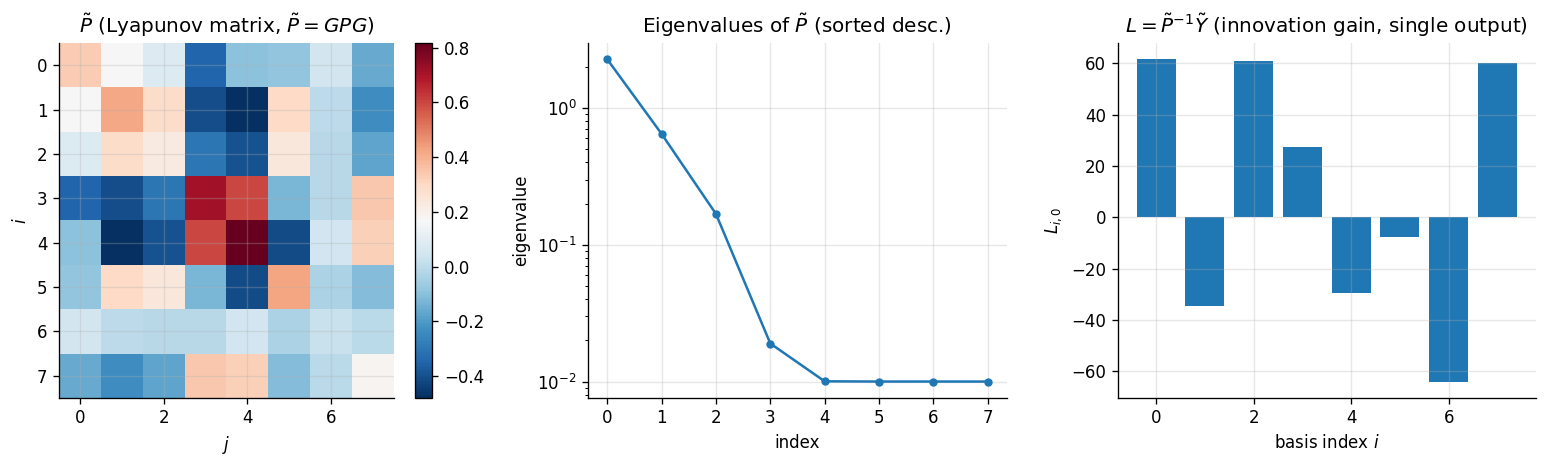

LMI max eigenvalue (should be ≤ 0)         : -9.9886e-04
X G⁻¹ P̃ G⁻ᵀ Xᵀ min eig (should be ≥ 1)  : 1.0000
max Re(eig(A_cl))     (should be < 0)      : -0.037325


In [22]:
import warnings; warnings.filterwarnings('ignore')

Ptilde = result['Ptilde']  # (n,n) Lyapunov matrix P̃ = GPG
Ytilde = result['Ytilde']  # (n,m) LMI gain variable Ỹ = GY
L      = result['L']       # (n,m) innovation gain L = P̃⁻¹Ỹ
A      = result['A']       # (n,n) drift matrix G⁻¹G'ᵀ
n      = Ptilde.shape[0]
X, H   = data.X_data, data.Y_data

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# ── P̃ matrix ──────────────────────────────────────────────────────────────
im0 = axes[0].imshow(Ptilde, aspect='auto', cmap='RdBu_r')
fig.colorbar(im0, ax=axes[0])
axes[0].set_title(r'$\tilde{P}$ (Lyapunov matrix, $\tilde{P}=GPG$)')
axes[0].set_xlabel('$j$'); axes[0].set_ylabel('$i$')

# ── Eigenvalues of P̃ ──────────────────────────────────────────────────────
eigs_P = np.sort(np.linalg.eigvalsh(Ptilde))[::-1]
axes[1].semilogy(np.arange(n), eigs_P, 'o-', markersize=4)
axes[1].set_title(r'Eigenvalues of $\tilde{P}$ (sorted desc.)')
axes[1].set_xlabel('index'); axes[1].set_ylabel('eigenvalue')

# ── Innovation gain L ─────────────────────────────────────────────────────
axes[2].bar(np.arange(n), L[:, 0])
axes[2].set_title(r'$L = \tilde{P}^{-1}\tilde{Y}$ (innovation gain, single output)')
axes[2].set_xlabel('basis index $i$'); axes[2].set_ylabel(r'$L_{i,0}$')

plt.tight_layout()
plt.show()

# ── LMI verification (standard Lyapunov form, equivalent to paper Eq. 19) ─
# P̃ A + Aᵀ P̃ − Ỹ H − Hᵀ Ỹᵀ + k XᵀX ⪯ 0  (with A = G⁻¹G'ᵀ)
k_val = 1.0
lmi = Ptilde @ A + A.T @ Ptilde - Ytilde @ H - H.T @ Ytilde.T + k_val * X.T @ X
print(f'LMI max eigenvalue (should be ≤ 0)         : {np.linalg.eigvalsh(lmi).max():.4e}')
G_reg = result['G_reg']
Xt    = np.linalg.solve(G_reg, X.T).T   # X G⁻¹
print(f'X G⁻¹ P̃ G⁻ᵀ Xᵀ min eig (should be ≥ 1)  : {np.linalg.eigvalsh(Xt @ Ptilde @ Xt.T).min():.4f}')
# Closed-loop matrix A_cl = A − L H
A_cl = A - L @ H
print(f'max Re(eig(A_cl))     (should be < 0)      : {np.linalg.eigvals(A_cl).real.max():.6f}')


## Example 9 — Koopman–Luenberger Observer Simulation

Using the synthesis result from Example 8 we simulate the observer (Eq. 23).
The observer ODE (paper Eq. 23)

$$G\dot{z}(t) = G^{\prime\top}z(t) + (P^{-1}Y)\bigl(y(t) - Hz(t)\bigr)$$

is converted to the standard stiff ODE by multiplying both sides by $G^{-1}$:

$$\dot{z} = \underbrace{G^{-1}G^{\prime\top} - G^{-1}(P^{-1}Y)H}_{A_{\mathrm{cl}}}z + \underbrace{G^{-1}(P^{-1}Y)}_{L}y(t)$$

The state estimate is $\hat{x}(t) = Xz(t)$ (paper Eq. 23, last line).

Because $G$ is ill-conditioned the ODE is stiff — the **Radau** solver is used.  
MOSEK is used for the LMI, guaranteeing an exact (`optimal`) solution.  
With $n=32$ basis points the observer converges from $z_0=0$ (uninformed start).
The residual steady-state tracking error reflects the finite-$n$ RKHS approximation bias.


In [23]:
import warnings; warnings.filterwarnings("ignore")
from dynamical_system import DynamicalSystem, synthesize_observer_gain, simulate_koopman_observer
from kernel import linear_kernel, sobolev_kernel
from scipy.integrate import solve_ivp

# ── System ────────────────────────────────────────────────────────────────
omega = 1.0
sho9 = DynamicalSystem(
    f=lambda x: np.array([x[1], -omega**2 * x[0]]),
    h=lambda x: np.array([x[0]]),
    n_states=2, n_outputs=1, name="SHO",
)

# ── Data & kernel ─────────────────────────────────────────────────────────
# n basis points; residual tracking error reflects the finite-n RKHS approximation bias.
np.random.seed(0)
kappa9   = linear_kernel() * sobolev_kernel(d=sho9.n_states, s=2.5, length_scale=1.0)
t_eval9  = np.linspace(0.0, 2.0, 21)
data9    = sho9.collect_data(side_lengths=1.5, n=75, tau=2.0, t_eval=t_eval9)

# ── Synthesise observer gain (LMI with P̃=GPG, Ỹ=GY as variables) ─────────
result9 = synthesize_observer_gain(
    data9, kappa9, lam=5.0, k=100.0, eps=1e-2, delta=1.0, margin=1e-2,
)
print(f'Synthesis status: {result9["status"]}')

# ── Check closed-loop stability ───────────────────────────────────────────
# A_cl = A − L H,  A = G⁻¹G'ᵀ (precomputed),  L = P̃⁻¹Ỹ (innovation gain)
A9    = result9["A"]           # (n,n) drift matrix (precomputed in synthesis)
L9    = result9["L"]           # (n,m) innovation gain
H9    = data9.Y_data           # (m,n) output matrix
A_cl9 = A9 - L9 @ H9
max_re = np.linalg.eigvals(A_cl9).real.max()
print(f'max Re(eig(A_cl)) = {max_re:.6f}  ({"STABLE" if max_re < 0 else "UNSTABLE"})')

# ── True SHO trajectory (dense output for y_func) ────────────────────────
t_obs9    = np.linspace(0.0, 30.0, 300)
sol_dense = solve_ivp(
    lambda t, x: sho9.vector_field(x), [t_obs9[0], t_obs9[-1]],
    np.array([1.0, 0.0]),
    method="Radau", rtol=1e-9, atol=1e-11, dense_output=True,
)
y_func9  = lambda t: sho9.output(sol_dense.sol(t))
x_true9  = sol_dense.sol(t_obs9)

# ── Observer simulation (z₀ = 0: completely uninformed start) ────────────
n9   = data9.n_samples
z09  = np.zeros(n9)
obs9 = simulate_koopman_observer(
    result9, data9, y_func9, z09,
    t_span=(t_obs9[0], t_obs9[-1]), t_eval=t_obs9,
)
print(f'Observer ODE: {obs9["sol"].message}')

err9 = np.linalg.norm(obs9["x_hat"] - x_true9, axis=0)
for t_chk in [0, 5, 10, 20, 30]:
    idx = int(t_chk / 30 * 299)
    print(f'  err(t={t_chk:2d}) = {err9[idx]:.4f}')


Synthesis status: optimal
max Re(eig(A_cl)) = -0.000028  (STABLE)
Observer ODE: The solver successfully reached the end of the integration interval.
  err(t= 0) = 1.0000
  err(t= 5) = 0.1112
  err(t=10) = 0.1878
  err(t=20) = 0.1399
  err(t=30) = 0.2680


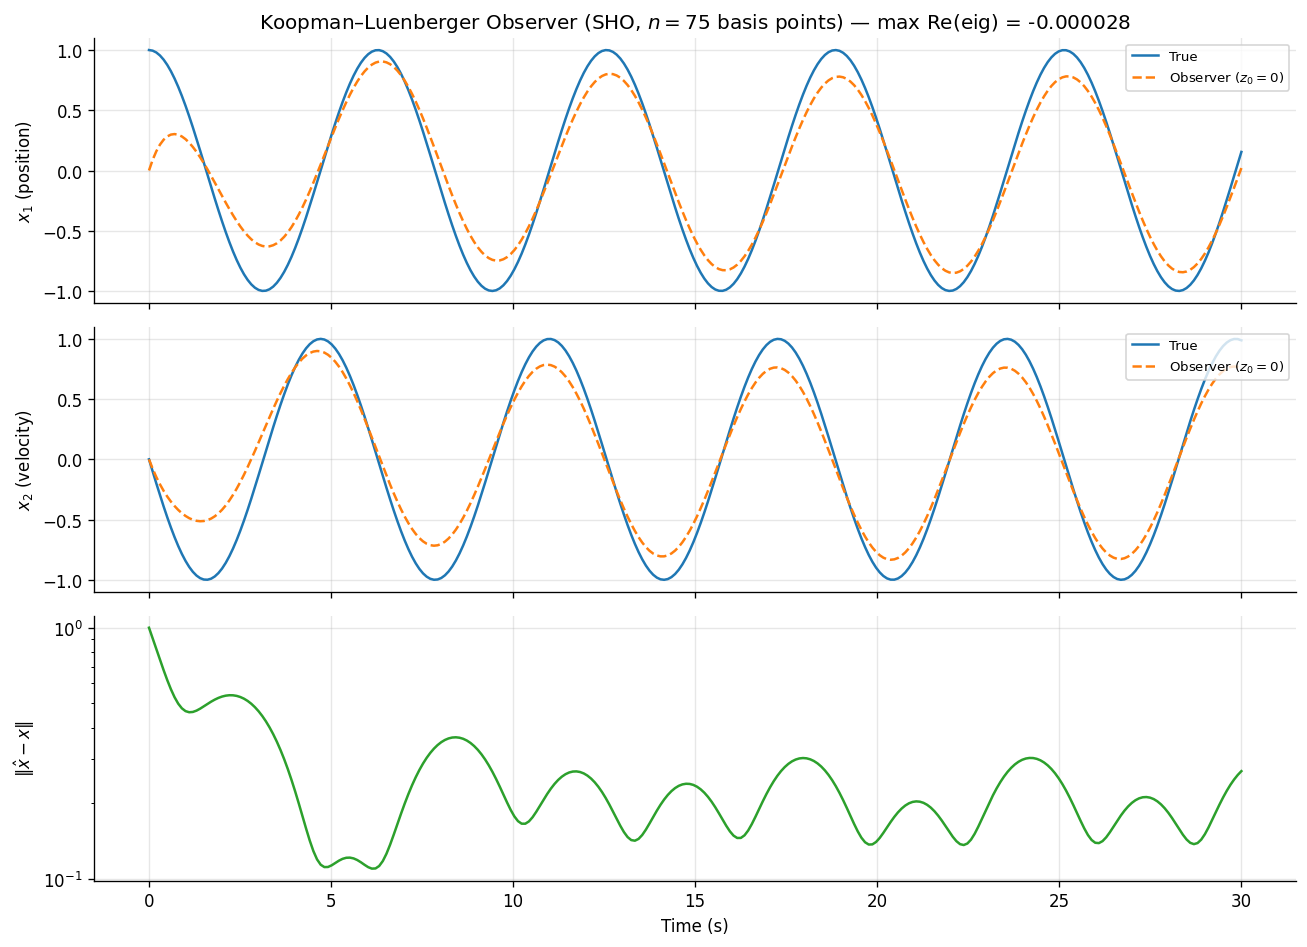

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

# ── State components ──────────────────────────────────────────────────────
labels = [r"$x_1$ (position)", r"$x_2$ (velocity)"]
for i, ax in enumerate(axes[:2]):
    ax.plot(t_obs9, x_true9[i],           "C0",    lw=1.5, label="True")
    ax.plot(obs9["t"], obs9["x_hat"][i],   "C1--",  lw=1.5, label=r"Observer ($z_0=0$)")
    ax.set_ylabel(labels[i])
    ax.legend(loc="upper right", fontsize=8)

# ── Estimation error ──────────────────────────────────────────────────────
axes[2].semilogy(t_obs9, err9, "C2", lw=1.5)
axes[2].set_ylabel(r"$\|\hat{x} - x\|$")
axes[2].set_xlabel("Time (s)")

axes[0].set_title(
    f"Koopman–Luenberger Observer (SHO, $n={n9}$ basis points) — "
    f"max Re(eig) = {max_re:.6f}",
)
plt.tight_layout()
plt.show()
